<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/03_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

# 3. 캐글 API로 MNIST 데이터 초고속 다운로드 및 압축 해제
!pip install -q kaggle

Mounted at /content/drive


In [ ]:
import torchvision
import torchvision.transforms as transforms

# 1. 전처리 정의 (기본적인 텐서 변환 및 정규화)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # R, G, B 채널 정규화
])

# 2. 데이터셋 로드
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
print(trainset.data.shape)

image, label = trainset[1]
print(image.shape)
print(label)

(50000, 32, 32, 3)
torch.Size([3, 32, 32])
9


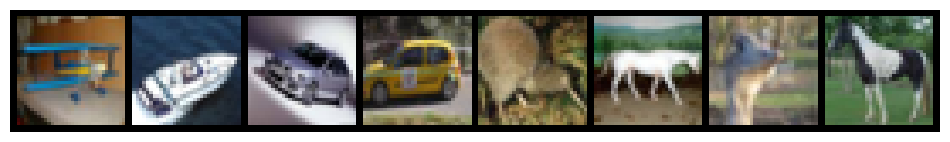

정답 라벨:  airplane | ship | automobile | automobile | bird | horse | bird | horse


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# CIFAR-10 클래스 이름 정의
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 텐서 변환 설정
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)

def imshow(img):
    npimg = img.numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images, nrow=8))

print("정답 라벨: ", ' | '.join(f'{classes[labels[j]]}' for j in range(8)))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # [블록 1] 특징 추출기 (Convolution)
        # 입력: 3채널(RGB 컬러), 출력: 16채널(16개의 서로 다른 특징을 찾겠다는 뜻)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)

        # [블록 2] 크기 축소기 (Pooling)
        # 2x2 크기에서 가장 큰 값만 뽑아내어, 이미지의 가로세로 크기를 절반으로 줄입니다.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # [블록 3] 최종 분류기 (Fully Connected / Linear)
        # conv1과 pool을 거친 후 이미지 크기는 16x16이 되고 채널은 16개입니다.
        # 이를 1차원으로 쭉 펼치면 (16 * 16 * 16) = 4096개의 숫자가 됩니다.
        # 이 4096개의 정보를 바탕으로 최종 정답 후보 10개(클래스 개수)의 점수를 냅니다.
        self.fc = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        # 1. 이미지를 훑고 (conv1), 활성화 함수(ReLU)를 켜고, 크기를 줄입니다. (pool)
        x = self.pool(F.relu(self.conv1(x)))

        # 2. 3차원 형태의 텐서를 1차원으로 길게 펼쳐줍니다.
        # x.size(0)은 배치를 유지하라는 뜻입니다.
        x = x.view(x.size(0), -1)

        # 3. 최종 점수 10개를 계산해서 내보냅니다.
        x = self.fc(x)
        return x

In [ ]:
import torch.optim as optim
model = SimpleCNN()

# 다중 클래스 분류(10개 중 하나 맞히기)에는 교차 엔트로피(Cross Entropy)가 표준입니다.
criterion = nn.CrossEntropyLoss()

# 가장 무난하고 성능이 잘 나오는 Adam을 사용합니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 3

for epoch in range(epochs):
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 2000 == 0:
            print(f"Epoch {epoch+1} Batch {i + 1:5d} | Loss: {running_loss/2000:.4f}")
            running_loss = 0.0

Epoch 1 Batch  2000 | Loss: 1.6478
Epoch 1 Batch  4000 | Loss: 1.3947
Epoch 1 Batch  6000 | Loss: 1.3321
Epoch 2 Batch  2000 | Loss: 1.2610
Epoch 2 Batch  4000 | Loss: 1.2456
Epoch 2 Batch  6000 | Loss: 1.2317
Epoch 3 Batch  2000 | Loss: 1.1729
Epoch 3 Batch  4000 | Loss: 1.1742
Epoch 3 Batch  6000 | Loss: 1.1676


In [ ]:
# 학습 데이터용 증강(Augmentation) 파이프라인
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 이미지를 좌우 반전합니다.
    transforms.RandomCrop(32, padding=4), # 이미지를 사방으로 4픽셀 늘린 뒤, 다시 32x32로 랜덤하게 잘라냅니다.
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 이제 본격적인 학습이니 정규화도 해줍니다.
])

# 테스트 데이터용 파이프라인 (테스트할 때는 원본 그대로 평가해야 하므로 증강을 빼야 합니다.)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 이미 로드된 주머니의 공장 설정을 교체해 줍니다.
trainset.transform = train_transform

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 첫 번째 Conv 블록 (입력 32 32)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # 두 번째 Conv 블록 (MaxPool을 거쳐 16 16으로 줄어든 상태에서 받음)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # 세 번째 Conv 블록 (MaxPool을 거쳐 8 8로 줄어든 상태에서 받음)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # 크기를 반토막 내는 풀링 레이어
        self.pool = nn.MaxPool2d(2, 2)

        # 최종 분류기(Linear 레이어)
        # 32 32 -> pool 세 번 통과 -> 16 16 -> 8 8 -> 4 4
        # 마지막 채널 수가 128이므로, 1차원으로 펼치면 (128 * 4 * 4) = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10) # 최종 10개 클래스 점수

        # 과적합 방지용 드롭아웃 (20%의 뉴런을 랜덤하게 끕니다.)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [ ]:
model = DeepCNN()
print(model)

DeepCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [ ]:
# 새 모델용 옵티마이저와 손실함수 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3

cnt = 500

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        images, labels = data

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % cnt == (cnt-1):
            print(f'[{epoch + 1}, {i + 1:5d}] 현재 오차(loss): {running_loss / cnt:.3f}')
            running_loss = 0.0

[1,   500] 현재 오차(loss): 1.183
[1,  1000] 현재 오차(loss): 1.122
[1,  1500] 현재 오차(loss): 1.130
[1,  2000] 현재 오차(loss): 1.092
[1,  2500] 현재 오차(loss): 1.079
[1,  3000] 현재 오차(loss): 1.076
[1,  3500] 현재 오차(loss): 1.059
[1,  4000] 현재 오차(loss): 1.060
[1,  4500] 현재 오차(loss): 1.067
[1,  5000] 현재 오차(loss): 1.028
[1,  5500] 현재 오차(loss): 1.055
[1,  6000] 현재 오차(loss): 1.023
[2,   500] 현재 오차(loss): 1.012
[2,  1000] 현재 오차(loss): 1.012
[2,  1500] 현재 오차(loss): 0.977
[2,  2000] 현재 오차(loss): 0.973
[2,  2500] 현재 오차(loss): 0.973
[2,  3000] 현재 오차(loss): 0.989
[2,  3500] 현재 오차(loss): 0.963
[2,  4000] 현재 오차(loss): 0.980
[2,  4500] 현재 오차(loss): 0.910
[2,  5000] 현재 오차(loss): 0.958
[2,  5500] 현재 오차(loss): 0.931
[2,  6000] 현재 오차(loss): 0.933
[3,   500] 현재 오차(loss): 0.913
[3,  1000] 현재 오차(loss): 0.885
[3,  1500] 현재 오차(loss): 0.904
[3,  2000] 현재 오차(loss): 0.933
[3,  2500] 현재 오차(loss): 0.910
[3,  3000] 현재 오차(loss): 0.873
[3,  3500] 현재 오차(loss): 0.861
[3,  4000] 현재 오차(loss): 0.874
[3,  4500] 현재 오차(loss): 0.880
[3,  5000]